In [1]:
!pip install statsforecast mlforecast neuralforecast

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsforecast import StatsForecast
from coreforecast.seasonal import find_season_length
from utilsforecast.plotting import plot_series
import seaborn as sns
from utilsforecast.losses import mae, rmse, smape, mase
from functools import partial
from utilsforecast.evaluation import evaluate
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
df = pd.read_csv('climate_EDA.csv', parse_dates=["date"], index_col = "date")
ts = ['co2_emission', 'energy_consumption']
exog_cols = ['humidity','urban_population', 'energy_price']
base_cols = ['unique_id', 'ds', 'y']

y = df.resample('W').agg({
    'co2_emission': 'mean',
    'energy_consumption': 'mean',
    'urban_population': 'mean',
    'humidity': 'mean',
    'energy_price': 'sum',
})

y = y.iloc[1:-2]

date_index = y.index

panel_list = [
    pd.DataFrame({
        'ds': y.index,
        'y': y[t].values,
        'unique_id': t,
        'urban_population': y['urban_population'].values,
        'humidity': y['humidity'].values,
        'energy_price': y['energy_price'].values
    })
    for t in ts
]

panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols + exog_cols]

FH = int(0.42 * y.shape[0])
df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

FREQ = y.index.freq
SEASON = 26
print(f"Frequency: {FREQ}, Season energy: {SEASON}")

Frequency: <Week: weekday=6>, Season energy: 26


**ML Предсказание**

In [4]:
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from mlforecast.utils import PredictionIntervals
from mlforecast.target_transforms import LocalStandardScaler
from functools import partial
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [5]:
date_features = ['week']
models={
        'lasso': Lasso(),
        'lin_reg': LinearRegression(),
        'ridge': Ridge(alpha=0.10),
        'rf': RandomForestRegressor(),
        'lgbm':LGBMRegressor(n_estimators=100, verbosity=-1),
}

LEVELS = [75, 90, 95]

fcst = MLForecast(
    models = models,
    freq=FREQ,
    date_features = date_features,
    target_transforms=[Differences([52])],
)
fcst.fit(df_train, )
fcst_sf = fcst.predict(h=FH, )

eval_mf = df_test[['unique_id', 'ds', 'y']].merge(
    fcst_sf,
    on=['unique_id', 'ds'],
    how='inner'
)

metrics = [mae, rmse, smape]
season_mase = partial(mase, seasonality=SEASON)
metrics +=[season_mase]
ml_metrics = evaluate(
    df=eval_mf,
    metrics=metrics,
    train_df=df_train
).set_index('metric')

ml_metrics

,unique_id,lasso,lin_reg,ridge,rf,lgbm
metric,,,,,,
mae,co2_emission,87.169104,87.198046,87.198042,105.637481,94.413931
mae,energy_consumption,6.755757,6.834305,6.834295,31.966458,18.725849
rmse,co2_emission,108.249259,108.274463,108.274459,130.729698,117.029130
rmse,energy_consumption,8.952117,9.063484,9.063469,42.303194,22.892381
smape,co2_emission,0.101286,0.101337,0.101337,0.125845,0.109973
smape,energy_consumption,0.539241,0.541180,0.541180,0.764301,0.749991
mase,co2_emission,1.115667,1.116038,1.116038,1.352042,1.208393
mase,energy_consumption,3.912166,3.957652,3.957647,18.511338,10.843883


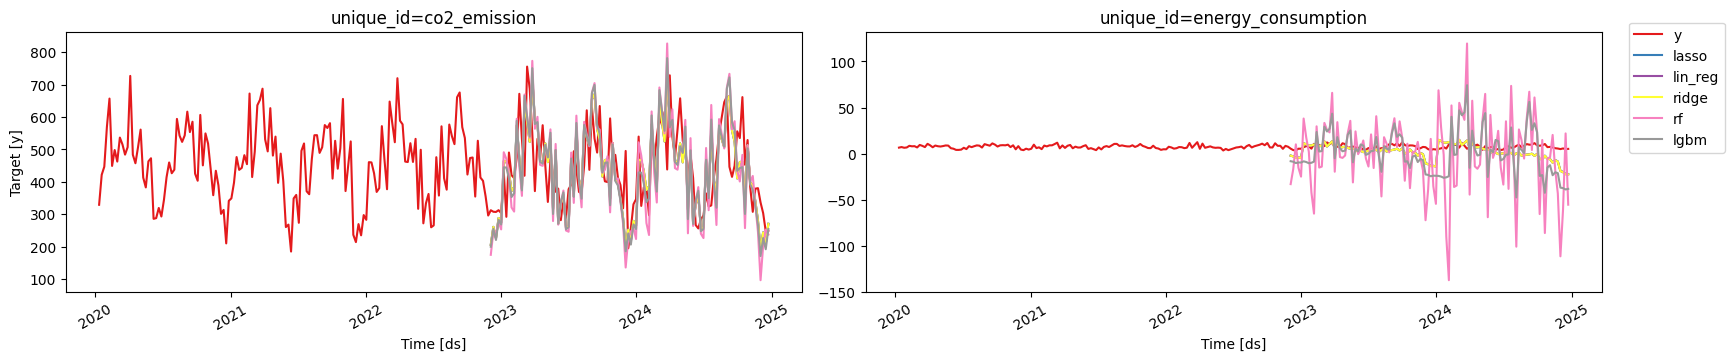

In [6]:
plot_series(
            df_train,
            forecasts_df=eval_mf,
            palette='Set1',
        )

Модели хорошо предсказывают данные для co2_emission, но плохо для energy_consumption. Проверим результаты если мы поменяем сезонность

                 unique_id     lasso   lin_reg     ridge        rf      lgbm
metric                                                                      
mae     energy_consumption  1.590632  1.601287  1.601287  2.289176  1.698275
rmse    energy_consumption  2.106873  2.128722  2.128722  2.912050  2.253683
smape   energy_consumption  0.109577  0.110354  0.110354  0.163053  0.117148
mase    energy_consumption  1.087524  1.094809  1.094809  1.565122  1.161120


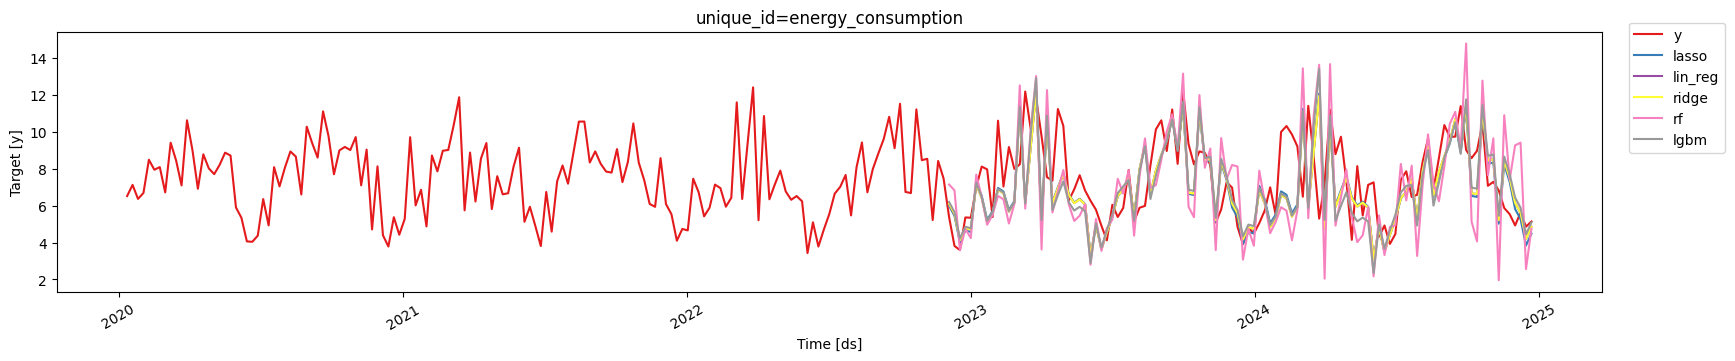

In [7]:
df_train_en = df_train[df_train['unique_id']=='energy_consumption']
fcst.fit(df_train_en, )
fcst_sf_en = fcst.predict(h=FH,  )

df_test_en = df_test[df_test['unique_id']=='energy_consumption']
eval_df_en = df_test_en[['unique_id', 'ds', 'y']].merge(
    fcst_sf_en,
    on=['unique_id', 'ds'],
    how='inner'
)

metrics = [mae, rmse, smape]
season_mase = partial(mase, seasonality=52)
metrics +=[season_mase]
ml_metrics_en = evaluate(
    df=eval_df_en,
    metrics=metrics,
    train_df=df_train
).set_index('metric')

print(ml_metrics_en)
plot_series(
            df_train_en,
            forecasts_df=eval_df_en,
            palette='Set1',
        )

Результаты для энергии значительно улучшились с годовой сезонностью

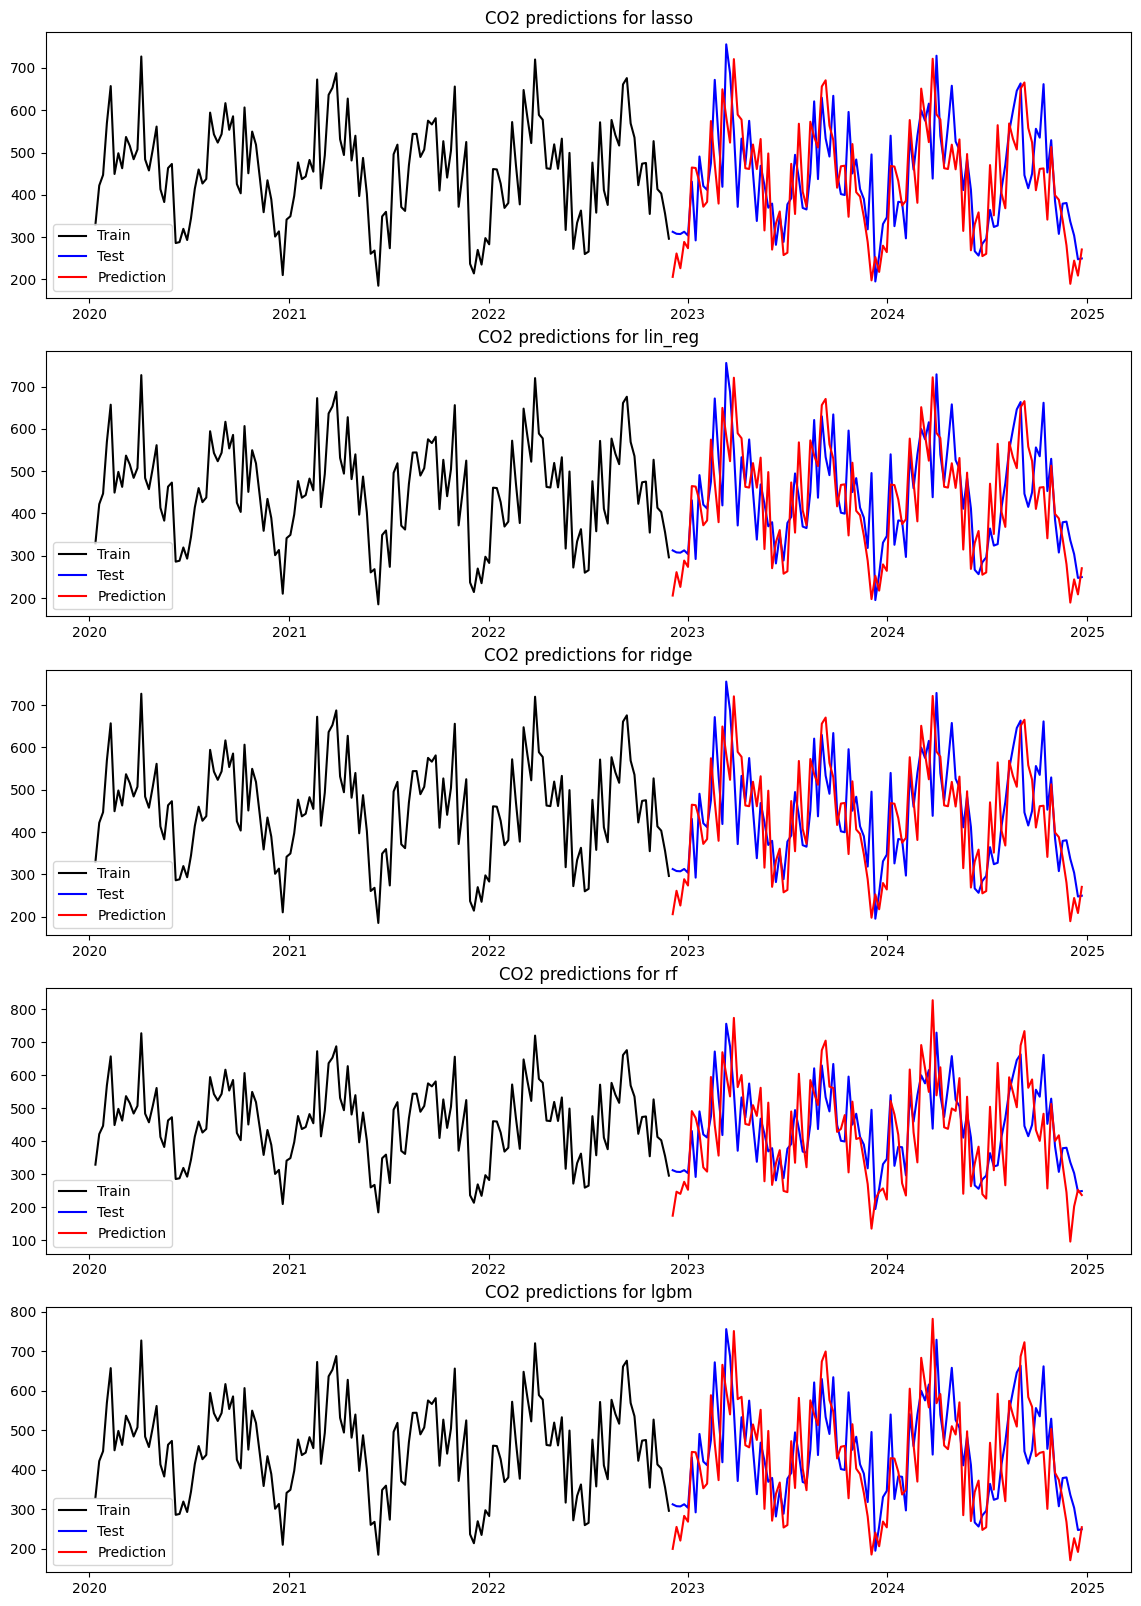

In [8]:
models = ['lasso',	'lin_reg',	'ridge',	'rf', 'lgbm']
fig, axes = plt.subplots(len(models), 1, figsize=(14, 4 * len(models)))
#test_len = len(df_test)
test_len = 108
df_train_tail = df_train[df_train['unique_id']=='co2_emission'].tail(test_len*3)
df_predict = eval_mf[eval_mf['unique_id']=='co2_emission'].head(test_len)
df_test_tail = df_test[df_test['unique_id']=='co2_emission'].head(test_len)
for i in range(len(models)):
  curr_model = models[i]
  axes[i].plot(df_train_tail['ds'], df_train_tail['y'], color = 'black', label='Train')
  axes[i].plot(df_test_tail['ds'], df_test_tail['y'], color = 'blue', label='Test')
  axes[i].plot(df_predict['ds'], df_predict[curr_model], color = 'red', label='Prediction')
  axes[i].set_title(f"CO2 predictions for {curr_model}")
  axes[i].legend()

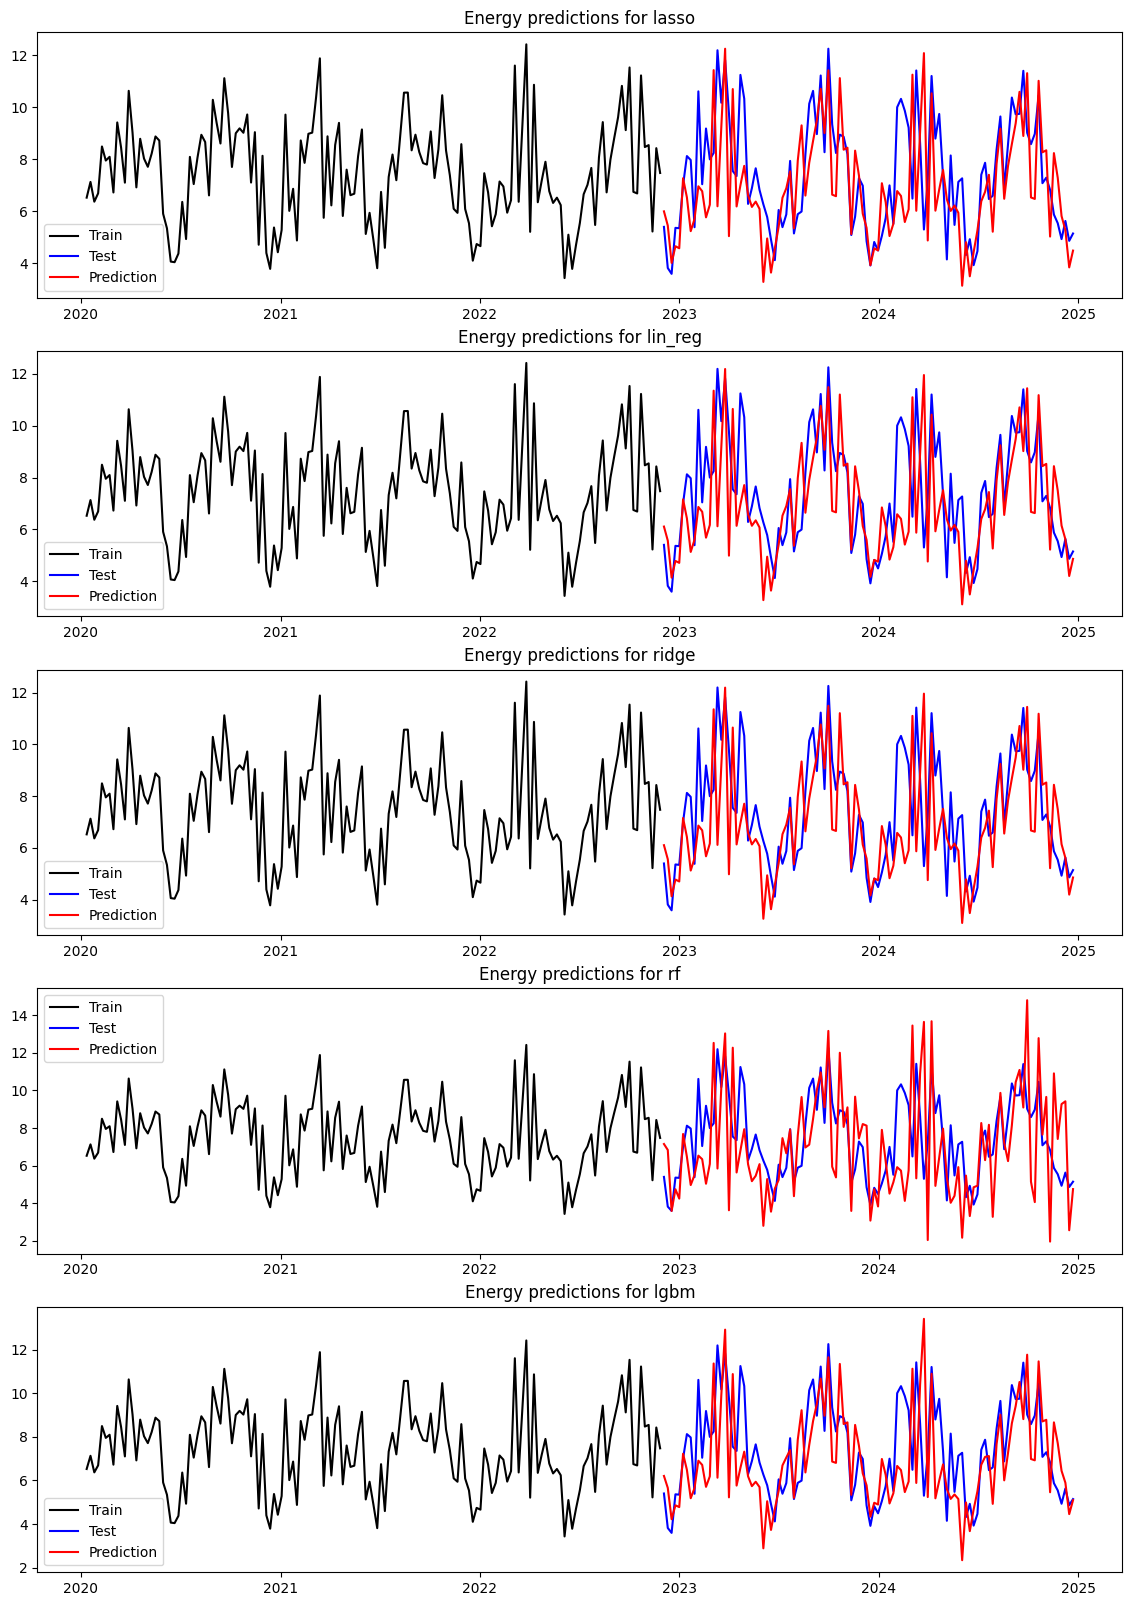

In [9]:
models = ['lasso',	'lin_reg',	'ridge',	'rf', 'lgbm']
fig, axes = plt.subplots(len(models), 1, figsize=(14, 4 * len(models)))
#test_len = len(df_test)
test_len = 108
df_train_tail = df_train_en.tail(test_len*3)
df_predict = eval_df_en.head(test_len)
df_test_tail = df_test_en.head(test_len)
for i in range(len(models)):
  curr_model = models[i]
  axes[i].plot(df_train_tail['ds'], df_train_tail['y'], color = 'black', label='Train')
  axes[i].plot(df_test_tail['ds'], df_test_tail['y'], color = 'blue', label='Test')
  axes[i].plot(df_predict['ds'], df_predict[curr_model], color = 'red', label='Prediction')
  axes[i].set_title(f"Energy predictions for {curr_model}")
  axes[i].legend()

# DL Модели

In [10]:
import neuralforecast
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NHITS, DLinear, Informer, TFT, PatchTST, LSTM
from ray import tune
from neuralforecast.auto import AutoNHITS

In [11]:
test_size = 26 #Равно SEASON
val_size = 26

In [12]:
horizon = test_size
log_path = ''

models = [
        LSTM(h=horizon, input_size = 3*horizon, max_steps=50, scaler_type='standard', encoder_hidden_size=128,  decoder_hidden_size=128, default_root_dir=log_path),
        NHITS(h=horizon, input_size = horizon, max_steps=50, n_freq_downsample=[1, 1, 1], default_root_dir=log_path),
        TFT(h=horizon, input_size = horizon, max_steps=50, hidden_size=128),
        PatchTST(h=horizon, input_size = horizon, max_steps=50,),
        LSTM(h=horizon, input_size = horizon, max_steps=50, encoder_hidden_size=128)
          ]

nf = NeuralForecast(models=models, freq=FREQ)
nf.fit(df=df_train)
y_hat = nf.predict(df_train)

eval_dl = df_test[['unique_id', 'ds', 'y']].merge(
    y_hat,
    on=['unique_id', 'ds'],
    how='inner'
)

dl_metrics = evaluate(
    df=eval_dl,
    metrics=metrics,
    train_df=df_train
).set_index('metric')

dl_metrics

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
/usr/local/lib/python3.12/dist-packages/neuralforecast/common/_base_model.py:602: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 199 K  | train
4 | mlp_decoder  | MLP           | 16

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,LSTM,NHITS,TFT,PatchTST,LSTM1
metric,,,,,,
mae,co2_emission,65.115301,79.330361,85.450335,73.307507,75.474743
mae,energy_consumption,1.342288,1.310407,1.423526,1.272077,1.342879
rmse,co2_emission,85.626202,94.543277,109.577979,88.779727,93.732550
rmse,energy_consumption,1.645313,1.614423,1.814071,1.534960,1.548654
smape,co2_emission,0.071607,0.089464,0.100268,0.082016,0.084289
smape,energy_consumption,0.087488,0.085386,0.091039,0.086120,0.088227
mase,co2_emission,0.844190,1.028482,1.107824,0.950398,0.978495
mase,energy_consumption,0.917730,0.895933,0.973273,0.869726,0.918134


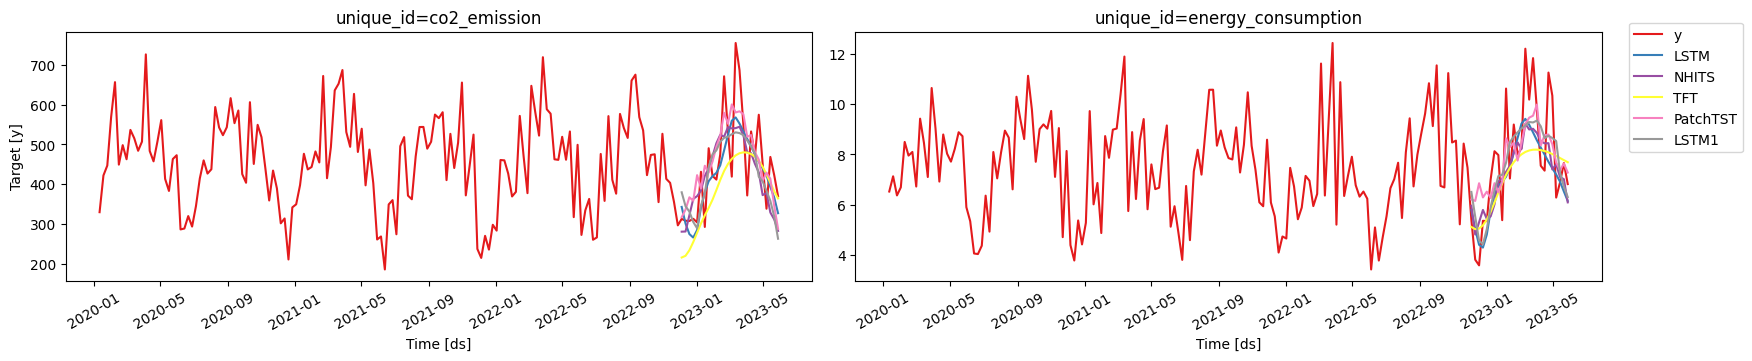

In [13]:
plot_series(
            df_train,
            forecasts_df=eval_dl,
            palette='Set1',
        )

In [14]:
ml_metrics_full = pd.concat([ml_metrics, ml_metrics_en])
avg_by_series_ml = ml_metrics.groupby(['unique_id', 'metric']).mean(numeric_only=True)
avg_by_series_ml.style.background_gradient(cmap='RdYlGn_r', axis=1).format(precision=2)

In [15]:
avg_by_series_dl = dl_metrics.groupby(['unique_id', 'metric']).mean(numeric_only=True)
avg_by_series_dl.style.background_gradient(cmap='RdYlGn_r', axis=1).format(precision=2)